In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/legalai/Query_doc.txt
/kaggle/input/legalai/README.txt
/kaggle/input/legalai/relevance_judgments_statutes.txt
/kaggle/input/legalai/relevance_judgments_priorcases.txt
/kaggle/input/legalai/AILA_2019_Overview_Paper.pdf
/kaggle/input/legalai/Object_casedocs/C757.txt
/kaggle/input/legalai/Object_casedocs/C1092.txt
/kaggle/input/legalai/Object_casedocs/C1985.txt
/kaggle/input/legalai/Object_casedocs/C39.txt
/kaggle/input/legalai/Object_casedocs/C2055.txt
/kaggle/input/legalai/Object_casedocs/C417.txt
/kaggle/input/legalai/Object_casedocs/C533.txt
/kaggle/input/legalai/Object_casedocs/C2.txt
/kaggle/input/legalai/Object_casedocs/C1812.txt
/kaggle/input/legalai/Object_casedocs/C2444.txt
/kaggle/input/legalai/Object_casedocs/C1240.txt
/kaggle/input/legalai/Object_casedocs/C2044.txt
/kaggle/input/legalai/Object_casedocs/C2367.txt
/kaggle/input/legalai/Object_casedocs/C1209.txt
/kaggle/input/legalai/Object_casedocs/C719.txt
/kaggle/input/legalai/Object_casedocs/C1286.txt
/kaggle/i

# Library

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util


2026-04-30 08:08:00.169866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777536480.343083      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777536480.391055      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load Queries

In [3]:
def load_queries(query_file_path):
    queries = {}
    with open(query_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('||')
            if len(parts) == 2:
                qid, qtext = parts
                queries[qid] = qtext
    return queries

queries = load_queries("/kaggle/input/legalai/Query_doc.txt")
query_ids = list(queries.keys())
query_texts = [queries[qid] for qid in query_ids]
print(f"✅ Loaded {len(queries)} queries.")


✅ Loaded 50 queries.


# TASK 1: Relevant Prior Cases

In [4]:
def load_cases(case_folder):
    case_texts = {}
    for filename in os.listdir(case_folder):
        if filename.startswith("C") and filename.endswith(".txt"):
            cid = filename[:-4]
            with open(os.path.join(case_folder, filename), 'r', encoding='utf-8') as f:
                case_texts[cid] = f.read()
    return case_texts

cases = load_cases("/kaggle/input/legalai/Object_casedocs")
case_ids = list(cases.keys())
case_texts = [cases[cid] for cid in case_ids]
print(f"✅ Loaded {len(cases)} case documents.")

✅ Loaded 2914 case documents.


#  Embed Queries & Cases Using BERT

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')
query_embeddings = model.encode(query_texts, convert_to_tensor=True, show_progress_bar=True)
case_embeddings = model.encode(case_texts, convert_to_tensor=True, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Rank Top Cases Using Cosine Similarity

In [6]:
def rank_cases_bert(query_ids, case_ids, query_embeddings, case_embeddings, top_k=5):
    results = []
    cos_scores = util.pytorch_cos_sim(query_embeddings, case_embeddings)
    
    for q_index, qid in enumerate(query_ids):
        top_results = torch.topk(cos_scores[q_index], k=top_k)
        for rank, (score, idx) in enumerate(zip(top_results.values, top_results.indices)):
            case_id = case_ids[idx]
            results.append(f"{qid} Q0 {case_id} {rank+1} {score.item():.6f} bert_run")
    
    return results

ranked_cases = rank_cases_bert(query_ids, case_ids, query_embeddings, case_embeddings)


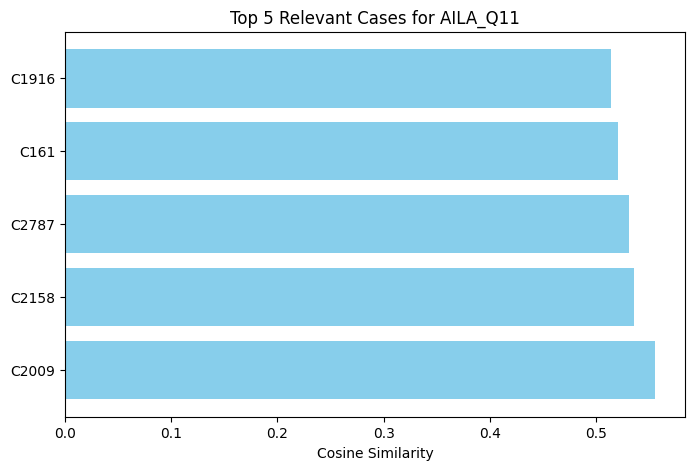

In [7]:
def plot_top_k_cases(query_id, ranked_list, top_k=5):
    top_k_df = pd.DataFrame(
        [r.split() for r in ranked_list if r.startswith(query_id)],
        columns=["query_id", "Q0", "doc_id", "rank", "score", "run_id"]
    ).head(top_k)
    
    scores = top_k_df["score"].astype(float).values
    doc_ids = top_k_df["doc_id"].values

    plt.figure(figsize=(8, 5))
    plt.barh(doc_ids[::-1], scores[::-1], color='skyblue')
    plt.xlabel("Cosine Similarity")
    plt.title(f"Top {top_k} Relevant Cases for {query_id}")
    plt.gca().invert_yaxis()
    plt.show()

plot_top_k_cases("AILA_Q11", ranked_cases)

# TASK 2: Relevant Statutes 

In [8]:
def load_statutes(statute_folder):
    """
    Load statute ID, title, and description from files.
    Returns:
        dict: { statute_id: full_text }
    """
    statutes = {}
    for filename in os.listdir(statute_folder):
        if filename.endswith(".txt") and filename.startswith("S"):
            sid = filename[:-4]  # remove .txt
            with open(os.path.join(statute_folder, filename), 'r', encoding='utf-8') as f:
                lines = f.readlines()
                if len(lines) >= 2:
                    title = lines[0].strip().replace("Title:", "").strip()
                    desc = lines[1].strip().replace("Desc:", "").strip()
                    full_text = f"{title}. {desc}"
                    statutes[sid] = full_text
    return statutes

statutes = load_statutes("/kaggle/input/legalai/Object_statutes")
statute_ids = list(statutes.keys())
statute_texts = [statutes[sid] for sid in statute_ids]
print(f"Loaded {len(statutes)} statutes.")


Loaded 197 statutes.


Encode Queries + Statutes

In [9]:
statute_embeddings = model.encode(statute_texts, convert_to_tensor=True, show_progress_bar=True)


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [10]:
def plot_top_k_statutes(query_id, ranked_list, top_k=5):
    top_k_df = pd.DataFrame(
        [r.split() for r in ranked_list if r.startswith(query_id)],
        columns=["query_id", "Q0", "doc_id", "rank", "score", "run_id"]
    ).head(top_k)
    
    scores = top_k_df["score"].astype(float).values
    doc_ids = top_k_df["doc_id"].values

    plt.figure(figsize=(8, 5))
    plt.barh(doc_ids[::-1], scores[::-1], color='lightgreen')
    plt.xlabel("Cosine Similarity")
    plt.title(f"Top {top_k} Relevant Statutes for {query_id}")
    plt.gca().invert_yaxis()
    plt.show()

plot_top_k_statutes("AILA_Q11", ranked_statutes)


NameError: name 'ranked_statutes' is not defined

# Saving

In [ ]:
def save_results_to_file(results, path):
    with open(path, "w", encoding='utf-8') as f:
        for line in results:
            f.write(line + "\n")

save_results_to_file(ranked_cases, "case_task1_bert_results.txt")
save_results_to_file(ranked_statutes, "task2_bert_statutes_results.txt")
print("✅ Results saved.")
